# Select best sorting

In [1]:
import pandas as pd
import numpy as np

In [2]:
maturity_stages_by_sex = {'female':{
                            "prepuberty": (2, 7),
                            "early-puberty": (7, 10),
                            "mid-puberty": (10, 13),
                            "late puberty": (13, 15),
                            "postpuberty": (15, 17),
                            "adulthood": (17, 30)
                        },

                        "male": {
                            "prepuberty": (3, 9),
                            "early-puberty": (9, 11),
                            "mid-puberty": (11, 13),
                            "late puberty": (13, 16),
                            "postpuberty": (16, 19),
                            "adulthood": (19, 30)
                        }
                        }

In [15]:
def find_frequent_joints_by_position(df, sex, min_age, max_age):
    filter_age_sex = df[(df['sex'] == sex) & (df['gp'] >= min_age) & (df['gp'] < max_age)].copy()

    if filter_age_sex.empty:
        return None

    # parse 'best_permutation' strings like '[7 2 5 6 4 1 3]' into integer lists
    perms = filter_age_sex['best_permutation'].apply(
        lambda x: np.fromstring(x.strip('[]'), dtype=int, sep=' ') if isinstance(x, str) else np.array(x)
    )
    filter_age_sex[['pos_1', 'pos_2', 'pos_3', 'pos_4', 'pos_5', 'pos_6', 'pos_7']] = pd.DataFrame(
        perms.tolist(), index=filter_age_sex.index
    )

    results = []
    for joint in [1, 2, 3, 4, 5, 6, 7]:
        frequency = []
        for position in ['pos_1', 'pos_2', 'pos_3', 'pos_4', 'pos_5', 'pos_6', 'pos_7']:
            frequency.append(len(filter_age_sex[filter_age_sex[position] == joint]))
        results.append(frequency)

    return calculate_fitness(results)

def calculate_fitness(results):
    # Define exponential weights for each position (these can be adjusted based on importance)
    position_weights = [1.6, 1.5, 1.4, 1.3, 1.2, 1.1, 1.0]
    joint_scores = []
    for joint_freq in results:
        score = sum(f * w for f, w in zip(joint_freq, position_weights))
        joint_scores.append(score)
    return sort_joints_by_fitness(joint_scores)

def sort_joints_by_fitness(joint_scores):
    joint_ids = list(range(1, 8))
    sorted_joints = sorted(zip(joint_ids, joint_scores), key=lambda x: x[1], reverse=True)
    return [joint_id for joint_id, score in sorted_joints]

In [16]:
df = pd.read_csv("sofi_results.csv")
df.head()

,k-fold,n_img,sex,gp,best_permutation,solution_fitness
0,0,0,200,5.00,[7 2 5 6 4 1 3],0.550675
1,0,1,100,6.83,[7 1 2 5 4 3 6],1.203897
2,0,2,200,5.00,[7 2 4 3 1 5 6],0.679063
3,0,3,100,6.83,[7 2 1 6 5 4 3],1.114874
4,0,4,200,6.00,[2 7 6 1 4 3 5],0.754718


In [17]:
df = pd.read_csv("sofi_results.csv")


for sex in maturity_stages_by_sex.keys():
    for stage, (min_age, max_age) in maturity_stages_by_sex[sex].items():
        print(f"Sex: {sex}, Stage: {stage}, Age Range: {min_age}-{max_age}")

        if sex == 'female':
            sex_norm = 100
        else:
            sex_norm = 200

        result = find_frequent_joints_by_position(df, sex_norm, min_age, max_age)
        print(result)

Sex: female, Stage: prepuberty, Age Range: 2-7
[7, 2, 6, 1, 5, 4, 3]
Sex: female, Stage: early-puberty, Age Range: 7-10
[7, 6, 2, 5, 1, 4, 3]
Sex: female, Stage: mid-puberty, Age Range: 10-13
[7, 2, 5, 6, 1, 3, 4]
Sex: female, Stage: late puberty, Age Range: 13-15
[7, 5, 2, 6, 3, 4, 1]
Sex: female, Stage: postpuberty, Age Range: 15-17
[7, 5, 2, 6, 1, 4, 3]
Sex: female, Stage: adulthood, Age Range: 17-30
[7, 2, 5, 6, 1, 3, 4]
Sex: male, Stage: prepuberty, Age Range: 3-9
[7, 2, 6, 1, 5, 4, 3]
Sex: male, Stage: early-puberty, Age Range: 9-11
[7, 6, 2, 5, 1, 4, 3]
Sex: male, Stage: mid-puberty, Age Range: 11-13
[7, 6, 2, 5, 1, 4, 3]
Sex: male, Stage: late puberty, Age Range: 13-16
[7, 5, 2, 6, 4, 3, 1]
Sex: male, Stage: postpuberty, Age Range: 16-19
[7, 5, 2, 6, 4, 3, 1]
Sex: male, Stage: adulthood, Age Range: 19-30
None


In [14]:
df = pd.read_csv("sofi_results.csv")


for sex in maturity_stages_by_sex.keys():
    for stage, (min_age, max_age) in maturity_stages_by_sex[sex].items():
        print(f"Sex: {sex}, Stage: {stage}, Age Range: {min_age}-{max_age}")

        if sex == 'female':
            sex_norm = 100
        else:
            sex_norm = 200

        result = find_frequent_joints_by_position(df, sex_norm, min_age, max_age)
        print(result)

Sex: female, Stage: prepuberty, Age Range: 2-7
[7, 2, 6, 1, 5, 4, 3]
Sex: female, Stage: early-puberty, Age Range: 7-10
[7, 6, 2, 5, 1, 3, 4]
Sex: female, Stage: mid-puberty, Age Range: 10-13
[7, 2, 5, 6, 4, 3, 1]
Sex: female, Stage: late puberty, Age Range: 13-15
[7, 5, 2, 6, 4, 1, 3]
Sex: female, Stage: postpuberty, Age Range: 15-17
[7, 5, 2, 6, 1, 3, 4]
Sex: female, Stage: adulthood, Age Range: 17-30
[2, 7, 5, 6, 1, 3, 4]
Sex: male, Stage: prepuberty, Age Range: 3-9
[7, 2, 6, 1, 5, 4, 3]
Sex: male, Stage: early-puberty, Age Range: 9-11
[7, 6, 2, 5, 1, 4, 3]
Sex: male, Stage: mid-puberty, Age Range: 11-13
[7, 6, 2, 1, 4, 5, 3]
Sex: male, Stage: late puberty, Age Range: 13-16
[7, 5, 2, 6, 4, 3, 1]
Sex: male, Stage: postpuberty, Age Range: 16-19
[7, 5, 2, 6, 1, 3, 4]
Sex: male, Stage: adulthood, Age Range: 19-30
None


In [6]:
df = pd.read_csv("sofi_results.csv")
df.head()

,k-fold,n_img,sex,gp,best_permutation,solution_fitness
0,0,0,200,5.00,[7 2 5 6 4 1 3],0.550675
1,0,1,100,6.83,[7 1 2 5 4 3 6],1.203897
2,0,2,200,5.00,[7 2 4 3 1 5 6],0.679063
3,0,3,100,6.83,[7 2 1 6 5 4 3],1.114874
4,0,4,200,6.00,[2 7 6 1 4 3 5],0.754718


In [37]:
sex = 200
low_limit=13
high_limit=16

df[(df['sex']==sex) & (df['gp']>low_limit) & (df['gp']<=high_limit)]

,k-fold,n_img,sex,gp,best_permutation,solution_fitness
48,0,49,200,13.25,[7 2 5 6 3 4 1],0.754805
53,0,54,200,13.25,[7 2 4 3 1 5 6],0.591226
55,0,56,200,14.00,[7 6 5 2 3 4 1],1.002748
56,0,57,200,13.25,[7 2 6 3 1 4 5],0.994258
58,0,59,200,14.00,[7 2 5 1 6 3 4],1.343247
59,0,60,200,14.00,[7 2 6 4 5 1 3],3.091119
60,0,61,200,13.25,[7 2 4 3 6 5 1],0.823531
61,0,62,200,15.50,[7 5 2 4 6 1 3],1.658174
62,0,63,200,15.00,[7 2 5 6 1 3 4],1.546752
65,0,66,200,14.00,[7 5 2 6 1 4 3],0.941125


In [ ]:
!pip3 install networkx
[7, 2, 5, 6, 1, 3, 4]



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


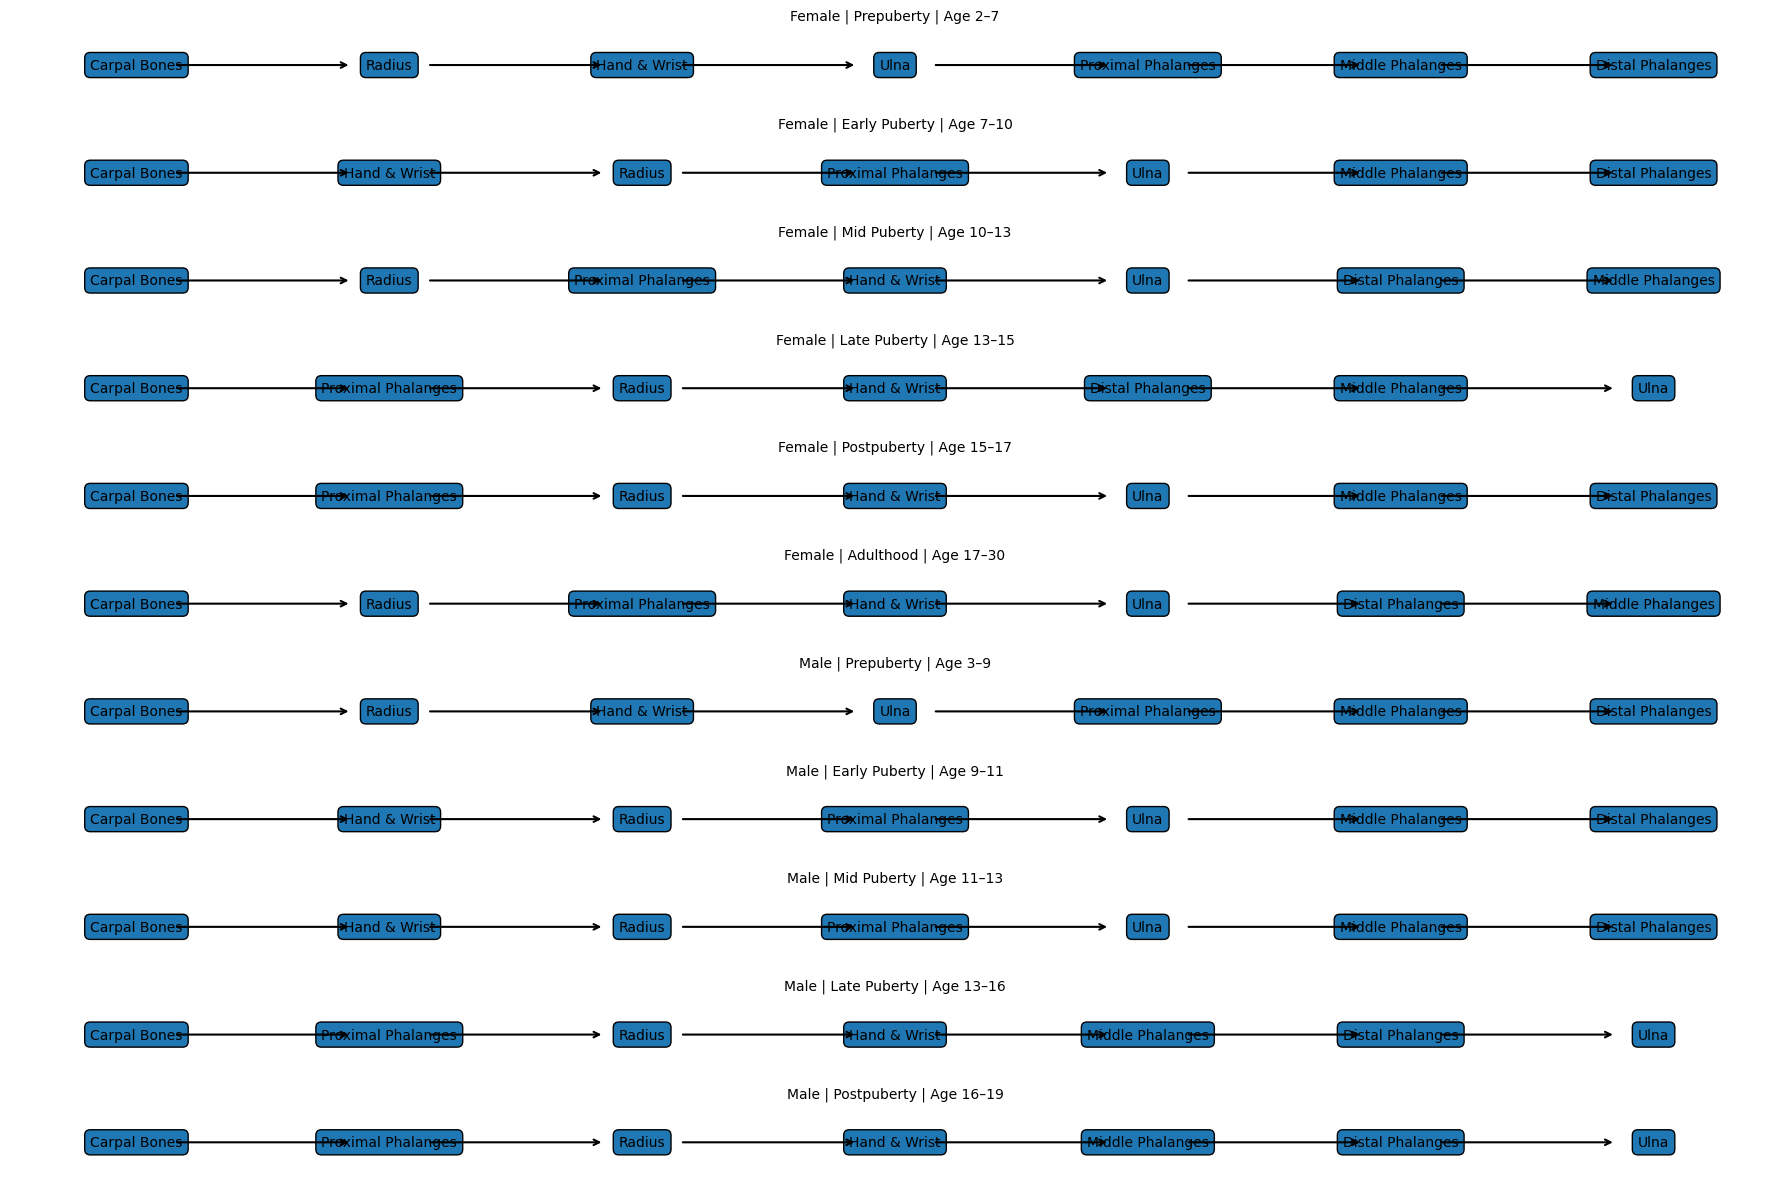

In [31]:
import matplotlib.pyplot as plt

labels = {
    1: "Ulna",
    2: "Radius",
    3: "Distal Phalanges",
    4: "Middle Phalanges",
    5: "Proximal Phalanges",
    6: "Hand & Wrist",
    7: "Carpal Bones"
}

data = [
    ("Female", "Prepuberty", "2–7", [7, 2, 6, 1, 5, 4, 3]),
    ("Female", "Early Puberty", "7–10", [7, 6, 2, 5, 1, 4, 3]),
    ("Female", "Mid Puberty", "10–13", [7, 2, 5, 6, 1, 3, 4]),
    ("Female", "Late Puberty", "13–15", [7, 5, 2, 6, 3, 4, 1]),
    ("Female", "Postpuberty", "15–17", [7, 5, 2, 6, 1, 4, 3]),
    ("Female", "Adulthood", "17–30", [7, 2, 5, 6, 1, 3, 4]),
    ("Male", "Prepuberty", "3–9", [7, 2, 6, 1, 5, 4, 3]),
    ("Male", "Early Puberty", "9–11", [7, 6, 2, 5, 1, 4, 3]),
    ("Male", "Mid Puberty", "11–13", [7, 6, 2, 5, 1, 4, 3]),
    ("Male", "Late Puberty", "13–16", [7, 5, 2, 6, 4, 3, 1]),
    ("Male", "Postpuberty", "16–19", [7, 5, 2, 6, 4, 3, 1]),
]

fig, axes = plt.subplots(len(data), 1, figsize=(18, 12))

for ax, (sex, stage, age, seq) in zip(axes, data):

    ax.axis("off")

    # Node positions
    xs = range(len(seq))

    # Draw nodes
    for i, node in enumerate(seq):
        ax.text(
            i, 0,
            labels[node],
            ha="center",
            va="center",
            bbox=dict(boxstyle="round,pad=0.4")
        )

    # Draw arrows
    for i in range(len(seq) - 1):
        ax.annotate(
            "",
            xy=(i + 1 - 0.15, 0),
            xytext=(i + 0.15, 0),
            arrowprops=dict(arrowstyle="->", lw=1.5)
        )

    ax.set_xlim(-0.5, len(seq) - 0.5)
    ax.set_ylim(-1, 1)

    ax.set_title(f"{sex} | {stage} | Age {age}", fontsize=10)

plt.tight_layout()
plt.show()